# 6.2 — Hierarchical Clustering

## The Problem with K-Means

K-Means has two problems:

**Problem 1 — Must specify K upfront.** What if you don't know how many groups exist? You'd have to guess K, run it, look at the result, guess again, run again — very inefficient.

**Problem 2 — One flat answer only.** K-Means tells you 'here are your 3 groups' and nothing more. It throws away all information about *relationships between groups*. Are group 1 and group 2 more similar to each other than to group 3? K-Means cannot tell you.

**Hierarchical Clustering fixes both.**

## The Analogy — Building a Family Tree

Imagine you have 6 FreshMart customers: Ravi, Meena, Arjun, Priya, Kumar, Nisha.

Instead of jumping to '3 groups', ask one simpler question repeatedly:

**'Which two are most similar right now? Merge them.'**

Round 1: Ravi and Meena are most similar → merge into **(Ravi+Meena)**  
Round 2: Arjun and Priya are most similar → merge into **(Arjun+Priya)**  
Round 3: Kumar and Nisha are most similar → merge into **(Kumar+Nisha)**  
Round 4: (Ravi+Meena) and (Arjun+Priya) are most similar → big group  
Round 5: Final merge → everyone

You've built a complete family tree from bottom to top. That tree is the **dendrogram.**

## How the Dendrogram Shows Relationships

This is what K-Means cannot do. Look at this dendrogram:

```
Distance
  |
8 |          ┌──────────────────────┐
  |          │                      │
3 |     ┌────┤                 ┌────┤
  |     │    │                 │    │
  |  Ravi  Meena           Kumar  Nisha
```

Ravi and Meena merged at height **3** — they are 3 units apart (very similar).  
The left group and right group merged at height **8** — they are 8 units apart (quite different).

K-Means gives you: 'Ravi is in cluster 0, Kumar is in cluster 1.' That's it.  
Hierarchical gives you: 'Ravi and Meena are very similar. They are quite different from Kumar and Nisha.'

Real use case: a doctor clustering patients by symptoms. K-Means says '3 groups exist.' Hierarchical says 'group A and B are actually similar — maybe two variants of the same condition. Group C is completely different.' That's clinically meaningful information K-Means cannot provide.

## The Real World Problem

Same FreshMart dataset — but now Meena wants more than just '3 groups.' She wants:
- Which segments are most similar to each other?
- If she wanted 2 broad groups instead of 3 — what would they be?
- She doesn't want to commit to K upfront — she wants to explore the full structure first.

**Hierarchical Clustering gives all of this from a single run.**

## How It Works — Agglomerative (Bottom-Up)

**Step 1 — Start:** N points → N clusters. Every customer is their own cluster.  
**Step 2 — Find closest pair:** Calculate distance between every pair of clusters. Find the two closest.  
**Step 3 — Merge:** Combine those two into one cluster. Now N-1 clusters.  
**Step 4 — Repeat:** Recalculate distances. Merge again. N-2 clusters.  
**Step 5 — Record:** Keep going until everything is one cluster. Record every merge.

The record of all merges = the **dendrogram.**

## Why Hierarchical is Slower than K-Means (Distance Calculation Comparison)

Both algorithms calculate distances — but the count is very different.

**K-Means:** Each point only calculates distance to **K centroids.**
```
500 customers, K=3:
Each iteration = 500 × 3 = 1,500 distance calculations
~10 iterations = 15,000 total
```

**Hierarchical:** At each step, every cluster calculates distance to **every other cluster.**
```
Step 1: 500 clusters → 500 × 499 / 2 = 124,750 distances
Step 2: 499 clusters → 499 × 498 / 2 = 124,251 distances
...
Total across all 499 steps ≈ hundreds of millions of calculations
```

K-Means compares each point to K centroids only. Hierarchical compares every cluster to every other cluster at every single merge step. That's why K-Means scales to millions of rows but Hierarchical gets slow above ~10,000.

## Linkage — How to Measure Distance Between Clusters

Once a cluster has multiple points, how do you measure distance between two clusters?

| Linkage | Definition | Problem |
|---|---|---|
| **Single** | Distance = distance between the two **closest** points | Chaining — one bridge point connects very different clusters |
| **Complete** | Distance = distance between the two **furthest** points | Conservative, compact clusters, but sensitive to outliers |
| **Ward** | Merge that **minimises the increase in inertia** | Best for most real-world data — sklearn default |

### Why Ward beats Single Linkage — the chaining effect

**Single linkage** only cares about the two closest individual points between two clusters. Imagine a long chain of customers in feature space:
```
* - * - * - * - * - * - * - * - * - *
```
Each consecutive pair is close. So single linkage keeps merging them one by one — creating one giant snaking cluster instead of distinct groups. One bridge point connects two completely different clusters.

**Ward** asks: 'If I merge these two clusters, how much does total inertia increase?' It looks at the **whole cluster** — not just one bridge point. Even if one outlier is close to the other cluster, merging would create a large, spread-out blob with high inertia. Ward avoids that merge. This is why Ward produces compact, balanced clusters similar in spirit to K-Means.

## Reproducibility — Why Hierarchical is Deterministic

**K-Means is not reproducible** without `random_state`. The random starting centroids change every run:
```
Run 1 → Cluster 0 = Budget customers
Run 2 → Cluster 0 = Affluent customers   ← same data, different answer
```

**Hierarchical is fully deterministic** — no randomness anywhere. Step 1 always merges the same two closest points. Step 2 always merges the same next pair. Given the same data and linkage method — you always get the exact same dendrogram. No `random_state` needed.

## Round Cluster Assumption — What It Means

**K-Means assumes round clusters** because it assigns every point to its nearest centroid. This naturally creates circular boundaries. If your real clusters are crescent-shaped, elongated, or interleaved — K-Means fails.

**Hierarchical depends on linkage:**
- **Ward** — assumes round, compact clusters (same as K-Means — minimises inertia)
- **Complete** — roughly round, conservative
- **Single** — can follow any shape (crescents, spirals) because it traces closest points — but has the chaining problem

DBSCAN (6.3) truly handles any shape without any of these assumptions.

## When to Use Hierarchical Even if You Know K

If your dataset is small (under ~5,000 rows) — prefer Hierarchical even when K is known:
- **Better cluster quality** — builds full tree first, then cuts. No random start, no local minima.
- **Deterministic** — same result every run.
- **One run → any K** — use `fcluster(Z, t=K, criterion='maxclust')` to get labels for any K without retraining.

If dataset is large → K-Means is the only practical choice.

## Key Concepts Table

| Concept | What it means |
|---|---|
| Agglomerative | Bottom-up — start with N clusters, merge until 1 |
| Dendrogram | Tree diagram showing every merge and at what distance |
| Merge height | Y-axis on dendrogram — how far apart the two groups were when merged |
| Cutting the dendrogram | Draw horizontal line — count crossings = K |
| Big gap in dendrogram | Best place to cut — groups below are naturally separate |
| Chaining effect | Single linkage flaw — one bridge point pulls distant clusters together |
| Ward linkage | Minimises inertia increase at each merge — compact, balanced clusters |
| Deterministic | No random init — same data always gives same dendrogram |
| Round cluster assumption | Ward and K-Means both prefer round clusters; Single linkage can follow any shape |
| Why not for large data | O(n²) pair distances at every step — K-Means only computes N×K distances per iteration |
| fcluster() | Cut linkage matrix Z at any K — no retraining needed |

In [1]:
# --- Imports ---
# scipy.cluster.hierarchy: dendrogram and linkage matrix
#   linkage(): computes the full merge tree
#   dendrogram(): visualises the merge tree
#   fcluster(): cuts the dendrogram at a given height to get flat cluster labels
# AgglomerativeClustering: sklearn's implementation (cleaner API, no dendrogram)
# silhouette_score: same metric as K-Means — measures cluster quality

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

np.random.seed(42)
print("Imports done.")

Imports done.


## Step 1 — Recreate the FreshMart Dataset

In [2]:
# Same 3-group FreshMart dataset as 6.1
# Regenerating here so notebook is self-contained

g1 = np.random.multivariate_normal(
    mean=[250, 25, 12, 400],
    cov=np.diag([30**2, 8**2, 3**2, 80**2]),
    size=180
)
g2 = np.random.multivariate_normal(
    mean=[800, 75, 3, 2500],
    cov=np.diag([80**2, 10**2, 1**2, 400**2]),
    size=160
)
g3 = np.random.multivariate_normal(
    mean=[480, 55, 7, 1100],
    cov=np.diag([50**2, 12**2, 2**2, 200**2]),
    size=160
)

X_raw = np.vstack([g1, g2, g3])
df = pd.DataFrame(X_raw, columns=['annual_income_k', 'spending_score', 'visit_frequency', 'avg_basket_size'])
df['annual_income_k'] = df['annual_income_k'].clip(100, 1200)
df['spending_score']  = df['spending_score'].clip(1, 100)
df['visit_frequency'] = df['visit_frequency'].clip(1, 20)
df['avg_basket_size'] = df['avg_basket_size'].clip(100, 5000)

# Scale — same reason as K-Means: distance-based, large features dominate otherwise
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

print(f"Dataset: {df.shape} | Scaled: {X_scaled.shape}")
df.head()

Dataset: (500, 4) | Scaled: (500, 4)


,annual_income_k,spending_score,visit_frequency,avg_basket_size
0,245.852071,30.181508,16.569090,439.737132
1,242.975891,37.633703,14.302304,381.267730
2,266.276801,21.292658,10.602811,362.442049
3,192.601593,11.200657,10.313137,419.356982
4,259.427420,17.735807,7.763089,318.973510


## Step 2 — Build the Linkage Matrix

Before we can draw the dendrogram, we need to compute the **linkage matrix** — this records every single merge:
- Which two clusters merged
- At what distance they merged
- How many points are in the new merged cluster

For 500 customers → 499 merges → 499 rows in the linkage matrix.

In [3]:
# --- Compute linkage matrix ---
# method='ward': use Ward linkage — minimise inertia increase at each merge
# metric='euclidean': use Euclidean distance (required for Ward)
# This computes ALL 499 merges for 500 customers
# Note: for large N this is slow — O(n²) — hierarchical doesn't scale

Z = linkage(X_scaled, method='ward', metric='euclidean')

print(f"Linkage matrix shape: {Z.shape}")
print(f"  {Z.shape[0]} rows = {len(df)-1} merges (one per step)")
print(f"  4 columns: [cluster_A, cluster_B, distance, size_of_new_cluster]")
print(f"\nFirst 5 merges (closest pairs merged first):")
print(pd.DataFrame(Z[:5], columns=['Cluster A', 'Cluster B', 'Distance', 'New Size']).round(4))
print(f"\nLast 5 merges (most distant groups merged last):")
print(pd.DataFrame(Z[-5:], columns=['Cluster A', 'Cluster B', 'Distance', 'New Size']).round(4))

Linkage matrix shape: (499, 4)
  499 rows = 499 merges (one per step)
  4 columns: [cluster_A, cluster_B, distance, size_of_new_cluster]

First 5 merges (closest pairs merged first):
   Cluster A  Cluster B  Distance  New Size
0      196.0      222.0    0.0206       2.0
1      413.0      485.0    0.0493       2.0
2      199.0      323.0    0.0671       2.0
3      272.0      306.0    0.0679       2.0
4       27.0      110.0    0.0682       2.0

Last 5 merges (most distant groups merged last):
   Cluster A  Cluster B  Distance  New Size
0      982.0      988.0    5.5841     111.0
1      989.0      994.0    7.1005     160.0
2      987.0      991.0   10.6813     180.0
3      995.0      996.0   28.0234     340.0
4      993.0      997.0   51.3250     500.0


## Step 3 — Draw the Dendrogram

The dendrogram visualises every merge. The **Y-axis is the distance** at which two groups merged.

**How to read it:**
- Low horizontal lines = similar things merged early
- High horizontal lines = very different groups forced to merge late
- **Big vertical gaps = natural separation between clusters** — this is where to cut

**How to pick K:**  
Draw a horizontal line across the dendrogram. Count how many vertical lines it crosses = K.  
Draw it in the biggest gap for the most natural K.

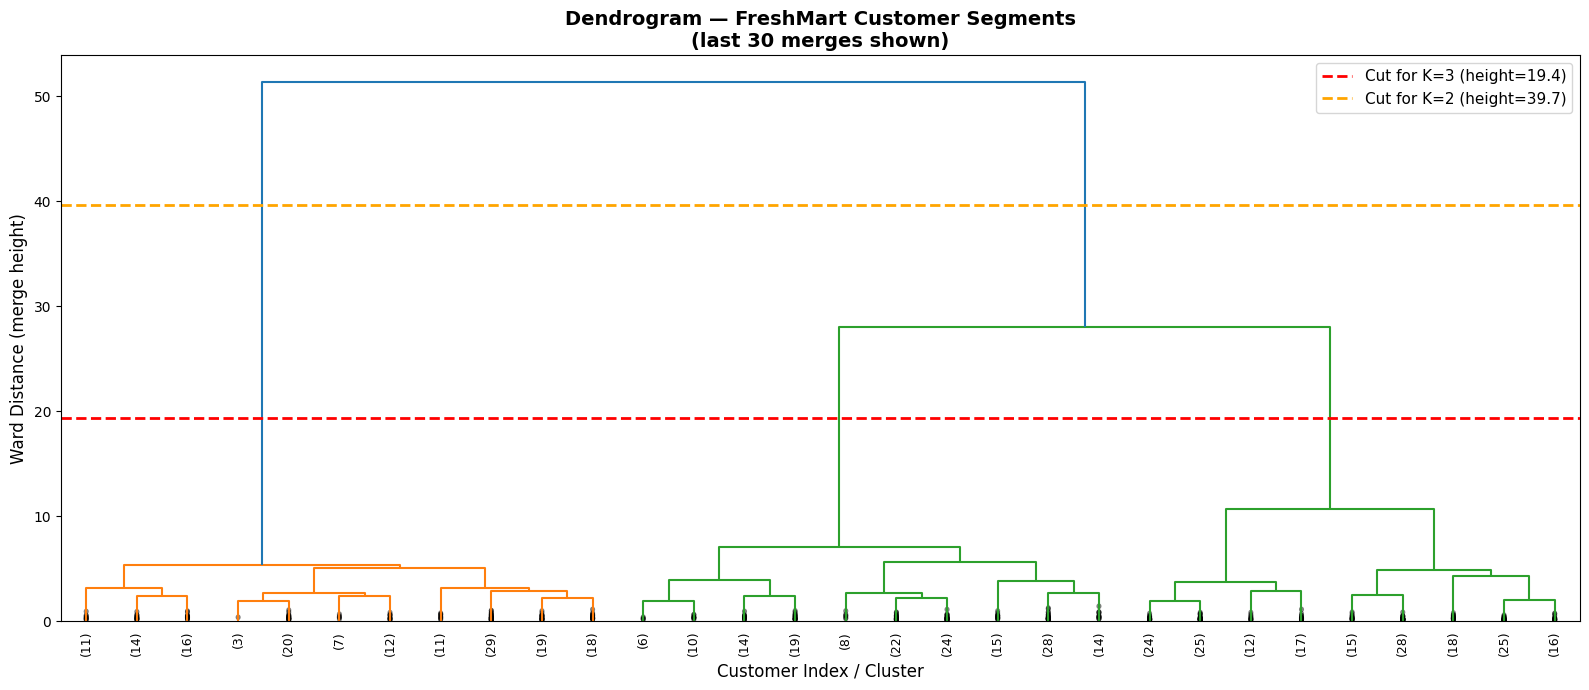

Reading the dendrogram:
  Red line (lower) crosses 3 vertical lines → K=3
  Orange line (higher) crosses 2 vertical lines → K=2
  The large gap between red and orange = natural separation → K=3 is the natural choice


In [4]:
# --- Full Dendrogram ---
# truncate_mode='lastp': show only the last p merges to keep it readable
#   (500 customers → full dendrogram is unreadable — too many leaves)
# p=30: show last 30 merges
# show_contracted=True: show count of hidden leaves as numbers
# color_threshold: colour branches that merge below this distance

fig, ax = plt.subplots(figsize=(16, 7))

dend = dendrogram(
    Z,
    truncate_mode='lastp',
    p=30,
    show_contracted=True,
    leaf_rotation=90,
    leaf_font_size=9,
    color_threshold=0.7 * max(Z[:, 2]),
    ax=ax
)

# Draw horizontal cut lines to show K=2 and K=3
# Find heights for K=2 and K=3 by looking at last few merges
last_merges = Z[-5:, 2]  # distances of last 5 merges
cut_k3 = (Z[-3, 2] + Z[-2, 2]) / 2  # between 3rd-last and 2nd-last merge
cut_k2 = (Z[-2, 2] + Z[-1, 2]) / 2  # between 2nd-last and last merge

ax.axhline(y=cut_k3, color='red', linestyle='--', linewidth=2, label=f'Cut for K=3 (height={cut_k3:.1f})')
ax.axhline(y=cut_k2, color='orange', linestyle='--', linewidth=2, label=f'Cut for K=2 (height={cut_k2:.1f})')

ax.set_xlabel('Customer Index / Cluster', fontsize=12)
ax.set_ylabel('Ward Distance (merge height)', fontsize=12)
ax.set_title('Dendrogram — FreshMart Customer Segments\n(last 30 merges shown)', 
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

print("Reading the dendrogram:")
print("  Red line (lower) crosses 3 vertical lines → K=3")
print("  Orange line (higher) crosses 2 vertical lines → K=2")
print("  The large gap between red and orange = natural separation → K=3 is the natural choice")

## Step 4 — Visualise the Gap

The dendrogram gap is easier to see in a merge distance plot — where we plot the distance at each merge step. The biggest **jump** in distance = where to cut.

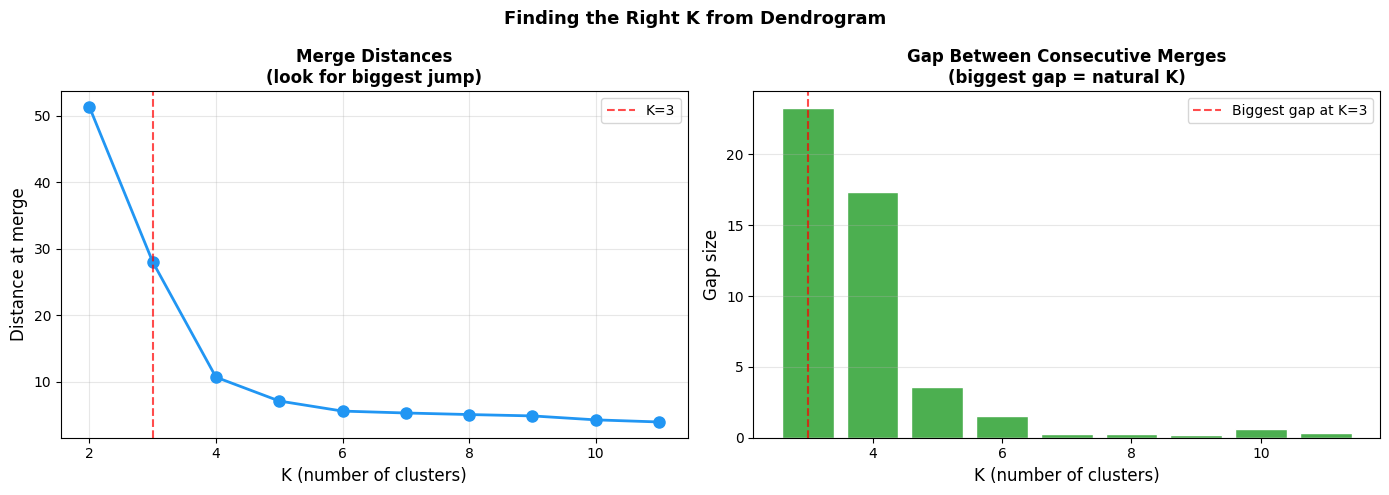

Biggest gap at K=3 — this is the natural number of clusters


In [5]:
# --- Merge distance plot ---
# Z[-k:, 2] = distances of the last k merges (largest distances = final merges)
# Reversing so K=2 is on the left, K=N on the right
# The biggest jump between consecutive distances = natural cut point

last_k = 10  # look at last 10 merges
merge_distances = Z[-last_k:, 2][::-1]  # reverse: index 0 = K=2, index 1 = K=3...
k_values = range(2, last_k + 2)

# Compute gaps between consecutive merge distances
gaps = np.diff(merge_distances[::-1])[::-1]  # gap[i] = jump when going from K=i+2 to K=i+1

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Merge distances
ax1.plot(list(k_values), merge_distances, 'o-', color='#2196F3', linewidth=2, markersize=8)
ax1.set_xlabel('K (number of clusters)', fontsize=12)
ax1.set_ylabel('Distance at merge', fontsize=12)
ax1.set_title('Merge Distances\n(look for biggest jump)', fontsize=12, fontweight='bold')
ax1.grid(alpha=0.3)
ax1.axvline(x=3, color='red', linestyle='--', alpha=0.7, label='K=3')
ax1.legend()

# Gaps between merges
ax2.bar(range(3, last_k + 2), gaps, color='#4CAF50', edgecolor='white')
ax2.set_xlabel('K (number of clusters)', fontsize=12)
ax2.set_ylabel('Gap size', fontsize=12)
ax2.set_title('Gap Between Consecutive Merges\n(biggest gap = natural K)', fontsize=12, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)
biggest_gap_k = np.argmax(gaps) + 3
ax2.axvline(x=biggest_gap_k, color='red', linestyle='--', alpha=0.7, label=f'Biggest gap at K={biggest_gap_k}')
ax2.legend()

plt.suptitle('Finding the Right K from Dendrogram', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Biggest gap at K={biggest_gap_k} — this is the natural number of clusters")

## Step 5 — Train AgglomerativeClustering with K=3

In [6]:
# --- sklearn AgglomerativeClustering ---
# n_clusters=3: we've decided K=3 from the dendrogram
# linkage='ward': minimise inertia increase — best for compact clusters
# metric='euclidean': required for Ward linkage
# Note: AgglomerativeClustering doesn't give a dendrogram directly
#   For dendrograms, use scipy.cluster.hierarchy (already done above)
#   For flat cluster labels (what we need for analysis), use AgglomerativeClustering

agg = AgglomerativeClustering(
    n_clusters=3,
    linkage='ward',
    metric='euclidean'
)
agg_labels = agg.fit_predict(X_scaled)

df['agg_cluster'] = agg_labels

# Silhouette score — same interpretation as K-Means: higher is better
sil = silhouette_score(X_scaled, agg_labels)

print(f"Silhouette Score (Hierarchical, K=3): {sil:.3f}")
print(f"\nCustomers per cluster:")
print(df['agg_cluster'].value_counts().sort_index())

Silhouette Score (Hierarchical, K=3): 0.577

Customers per cluster:
agg_cluster
0    180
1    160
2    160
Name: count, dtype: int64


## Step 6 — Compare All Three Linkage Methods

Seeing how Single, Complete, and Ward linkage produce very different results on the same data.

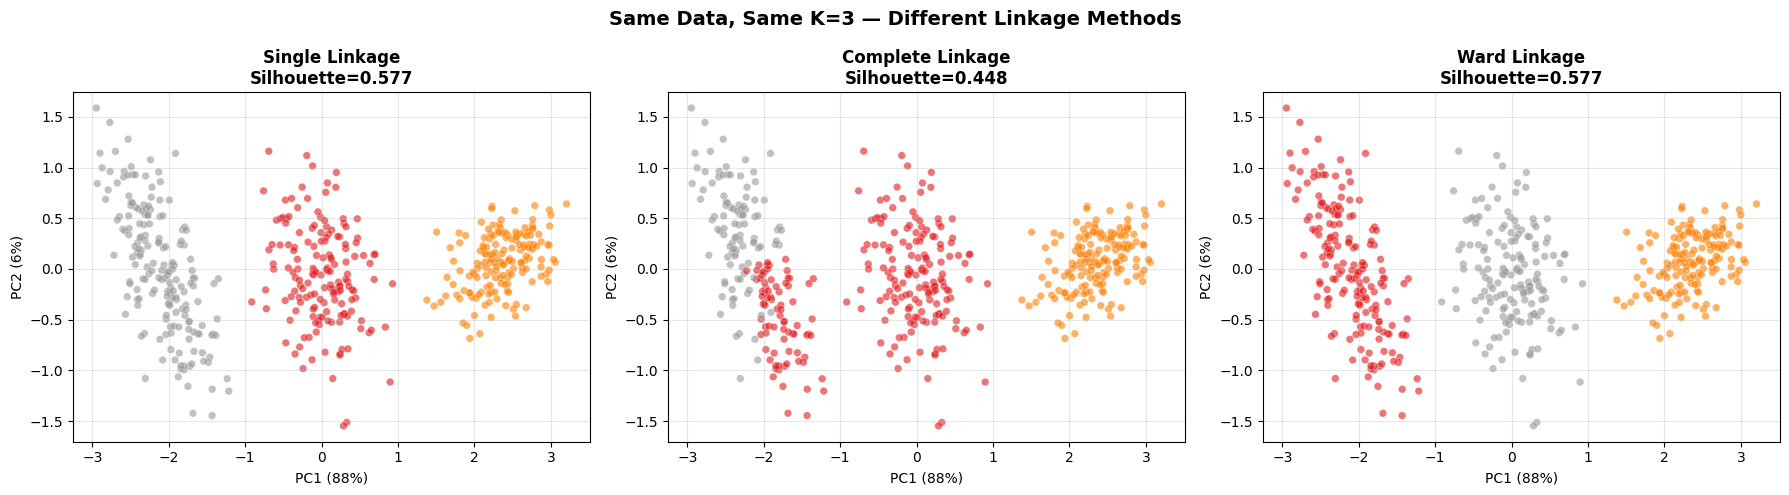

Single linkage: chaining effect — one cluster dominates, others are tiny
Complete linkage: more balanced but can be conservative
Ward linkage: compact, balanced clusters — highest silhouette score


In [7]:
# --- Compare linkage methods ---
# We'll use PCA to project to 2D, then plot clusters from each linkage method side by side
# This shows visually why Ward produces the most sensible clusters

pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_scaled)

linkage_methods = ['single', 'complete', 'ward']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, method in zip(axes, linkage_methods):
    model = AgglomerativeClustering(n_clusters=3, linkage=method)
    labels = model.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    
    scatter = ax.scatter(X_2d[:, 0], X_2d[:, 1], 
                         c=labels, cmap='Set1', alpha=0.6, s=30, edgecolors='white', linewidth=0.3)
    ax.set_title(f'{method.capitalize()} Linkage\nSilhouette={sil:.3f}', 
                 fontsize=12, fontweight='bold')
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.0f}%)')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.0f}%)')
    ax.grid(alpha=0.3)

plt.suptitle('Same Data, Same K=3 — Different Linkage Methods', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Single linkage: chaining effect — one cluster dominates, others are tiny")
print("Complete linkage: more balanced but can be conservative")
print("Ward linkage: compact, balanced clusters — highest silhouette score")

## Step 7 — Analyse and Name Clusters

In [8]:
# --- Cluster profiles ---
# Same approach as K-Means: group by cluster, compute mean of every feature
# Then manually interpret and name each cluster

profile = df.groupby('agg_cluster')[['annual_income_k', 'spending_score', 
                                      'visit_frequency', 'avg_basket_size']].mean().round(1)
print("=== Hierarchical Clustering — Cluster Profiles ===")
print(profile)

# Name clusters based on profiles
cluster_names = {}
for c in range(3):
    row = profile.loc[c]
    if row['annual_income_k'] < 400:
        cluster_names[c] = 'Budget Regulars'
    elif row['annual_income_k'] > 600:
        cluster_names[c] = 'Occasional Affluent'
    else:
        cluster_names[c] = 'Young Mid-Spenders'

df['agg_segment'] = df['agg_cluster'].map(cluster_names)
print("\nCluster names:", cluster_names)

=== Hierarchical Clustering — Cluster Profiles ===
             annual_income_k  spending_score  visit_frequency  avg_basket_size
agg_cluster                                                                   
0                      250.8            25.0             12.0            394.8
1                      800.8            75.7              3.1           2553.5
2                      488.1            55.7              7.1           1105.6

Cluster names: {0: 'Budget Regulars', 1: 'Occasional Affluent', 2: 'Young Mid-Spenders'}


## Step 8 — K-Means vs Hierarchical: Side by Side

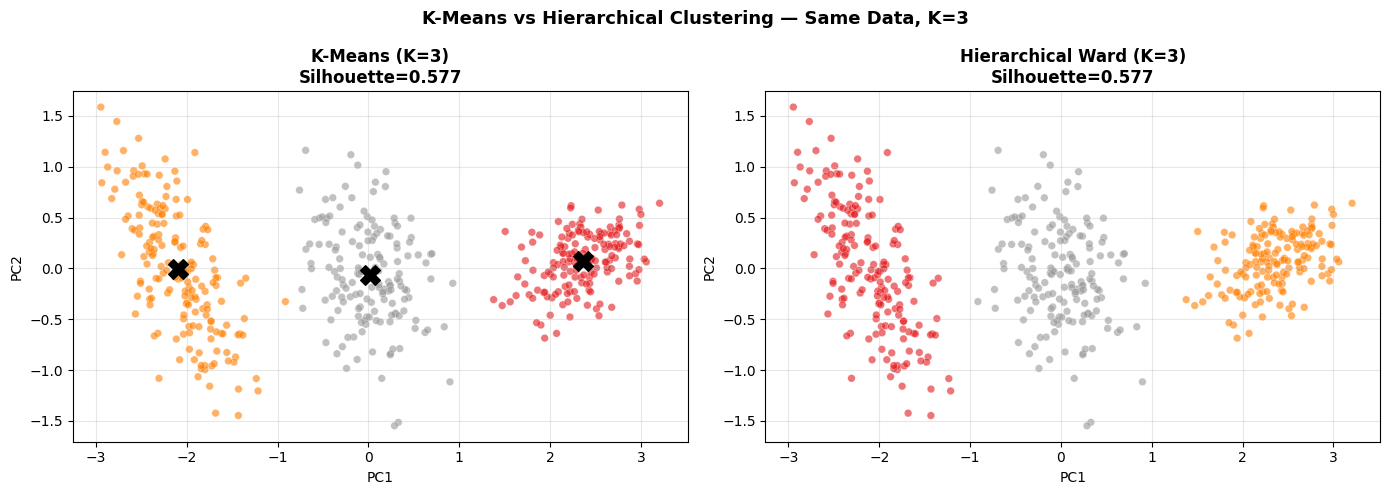

K-Means Silhouette:      0.577
Hierarchical Silhouette: 0.577

For well-separated, roughly spherical clusters (like this dataset),
both methods should give very similar results.


In [9]:
# --- K-Means vs Hierarchical (Ward) side by side ---
# Both used K=3, same scaled data
# How different are the results?
# Note: cluster numbers are arbitrary — 0 in K-Means ≠ 0 in Hierarchical
# We compare by silhouette score and visual inspection

from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, init='k-means++', n_init=10, random_state=42)
km_labels = kmeans.fit_predict(X_scaled)
km_sil = silhouette_score(X_scaled, km_labels)
agg_sil = silhouette_score(X_scaled, agg_labels)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.scatter(X_2d[:, 0], X_2d[:, 1], c=km_labels, cmap='Set1', alpha=0.6, s=30, edgecolors='white', linewidth=0.3)
# K-Means centroids
centroids_2d = pca.transform(kmeans.cluster_centers_)
ax1.scatter(centroids_2d[:, 0], centroids_2d[:, 1], c='black', marker='X', s=200, zorder=5)
ax1.set_title(f'K-Means (K=3)\nSilhouette={km_sil:.3f}', fontsize=12, fontweight='bold')
ax1.set_xlabel('PC1'); ax1.set_ylabel('PC2'); ax1.grid(alpha=0.3)

ax2.scatter(X_2d[:, 0], X_2d[:, 1], c=agg_labels, cmap='Set1', alpha=0.6, s=30, edgecolors='white', linewidth=0.3)
ax2.set_title(f'Hierarchical Ward (K=3)\nSilhouette={agg_sil:.3f}', fontsize=12, fontweight='bold')
ax2.set_xlabel('PC1'); ax2.set_ylabel('PC2'); ax2.grid(alpha=0.3)

plt.suptitle('K-Means vs Hierarchical Clustering — Same Data, K=3', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"K-Means Silhouette:      {km_sil:.3f}")
print(f"Hierarchical Silhouette: {agg_sil:.3f}")
print("\nFor well-separated, roughly spherical clusters (like this dataset),")
print("both methods should give very similar results.")

## Step 9 — The Unique Power of Hierarchical: Exploring Different K

One run → any K you want. No re-training needed. Just cut the dendrogram at a different height.

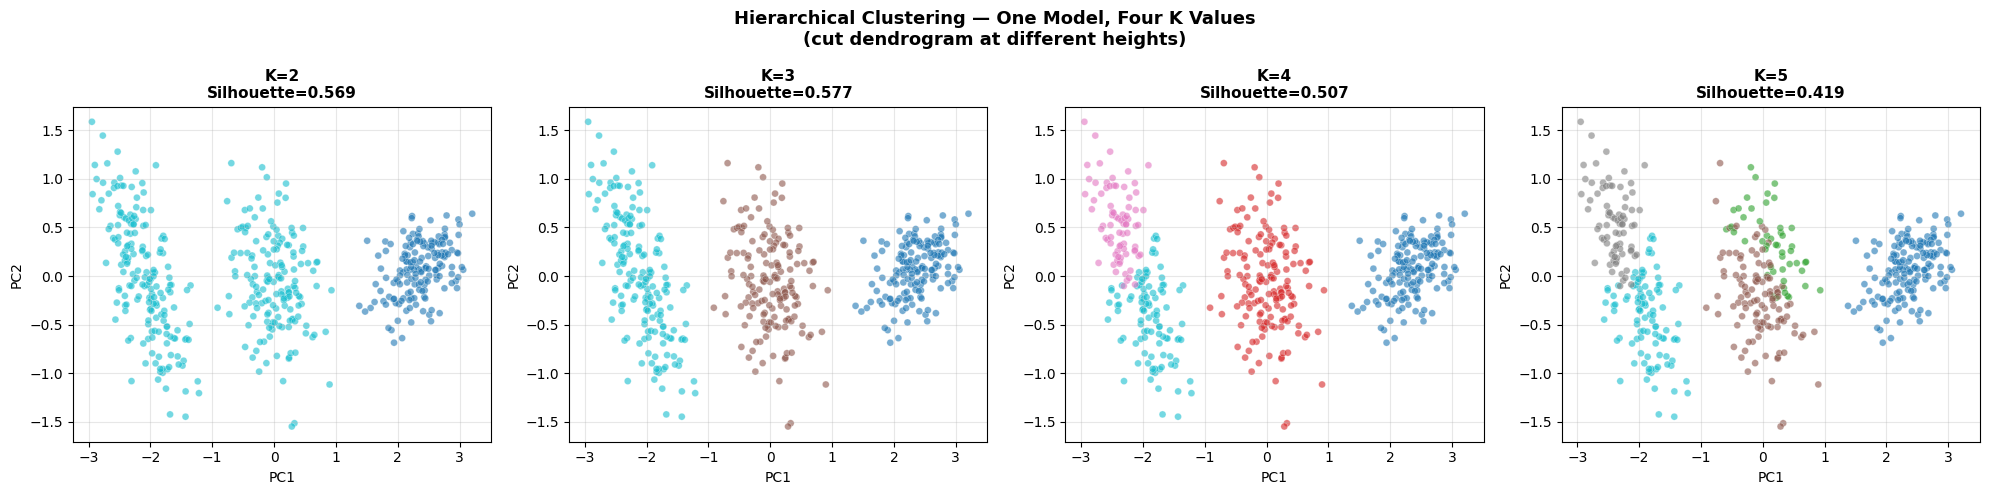

K-Means would require 4 separate training runs for this.
Hierarchical: one linkage matrix → any K instantly via fcluster.

Rule of thumb:
  Dataset < 5,000 rows  → prefer Hierarchical (even with known K)
  Dataset > 5,000 rows  → use K-Means (Hierarchical too slow)


In [10]:
# --- One model, multiple K values ---
# fcluster() cuts the linkage matrix Z at a given K to produce flat labels
# criterion='maxclust': cut to get exactly t clusters
#
# KEY INSIGHT: even if you KNOW K upfront, Hierarchical + fcluster is often BETTER than K-Means
# because:
#   1. No random init — no local minima risk
#   2. Deterministic — same result every time
#   3. One run → any K instantly without retraining
# The only reason to prefer K-Means is dataset SIZE — hierarchical is too slow above ~10k rows

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, k in zip(axes, [2, 3, 4, 5]):
    labels = fcluster(Z, t=k, criterion='maxclust')
    sil = silhouette_score(X_scaled, labels)
    
    ax.scatter(X_2d[:, 0], X_2d[:, 1], 
               c=labels, cmap='tab10', alpha=0.6, s=25, edgecolors='white', linewidth=0.3)
    ax.set_title(f'K={k}\nSilhouette={sil:.3f}', fontsize=11, fontweight='bold')
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.grid(alpha=0.3)

plt.suptitle('Hierarchical Clustering — One Model, Four K Values\n(cut dendrogram at different heights)', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("K-Means would require 4 separate training runs for this.")
print("Hierarchical: one linkage matrix → any K instantly via fcluster.")
print("\nRule of thumb:")
print("  Dataset < 5,000 rows  → prefer Hierarchical (even with known K)")
print("  Dataset > 5,000 rows  → use K-Means (Hierarchical too slow)")

## K-Means vs Hierarchical — Full Comparison

| | K-Means | Hierarchical (Ward) |
|---|---|---|
| **Need to specify K?** | Yes — upfront | No — cut dendrogram wherever you want |
| **Result** | Flat clusters only | Full tree showing relationships between clusters |
| **Scales to large data?** | Yes — only N×K distances per iteration | No — O(n²) pair distances at every step |
| **Reproducible?** | No — random centroid init changes result each run | Yes — deterministic, no randomness anywhere |
| **Handles non-round clusters?** | No — round boundary assumption | Ward=No, Single=Yes (but chaining problem) |
| **Can explore multiple K?** | Requires separate retraining for each K | One run → fcluster at any K instantly |
| **Shows cluster relationships?** | No — just labels | Yes — dendrogram shows merge distances |
| **Best for** | Large datasets (>5k rows) | Small/medium data, unknown K, exploring structure |
| **When to use even with known K** | Dataset is large | Dataset is small — better quality, deterministic |

## Summary Table

| Concept | What it means |
|---|---|
| Agglomerative | Bottom-up merging — start with N clusters, keep merging until 1 |
| Dendrogram | Tree of all merges — Y-axis is the distance at which two groups merged |
| Merge height | High = groups were very different when merged. Low = very similar. |
| Cluster relationships | Dendrogram height tells you HOW similar two clusters are — K-Means cannot |
| Cutting the dendrogram | Horizontal line → count crossings = K. Cut at biggest vertical gap. |
| Ward linkage | Merge that minimises inertia increase — compact, balanced, round clusters |
| Single linkage | Merge closest pair — can follow any shape but prone to chaining |
| Chaining effect | One bridge point pulls two distant clusters together — single linkage flaw |
| Deterministic | No random init — same data + same linkage = same dendrogram every time |
| Round cluster assumption | Ward=yes (like K-Means), Single=no (any shape but chaining risk) |
| Why not for large data | O(n²) pair distances at every step vs K-Means's N×K per iteration |
| fcluster(Z, t=K) | Cut linkage matrix at K — flat labels with no retraining |
| When to prefer over K-Means | Dataset < 5k rows — better quality, deterministic, one run any K |

## Practice Task

Priya is a biology researcher in Kochi. She has measurements of **150 plant samples** across 3 species:
- `petal_length_cm`
- `petal_width_cm`
- `sepal_length_cm`
- `sepal_width_cm`

She does NOT know how many species are in the data — she wants to discover it from the structure.

**Your tasks:**
1. Load the Iris dataset from sklearn (`from sklearn.datasets import load_iris`) — use only the features, not the labels
2. Scale the features
3. Build the linkage matrix with Ward linkage
4. Draw the dendrogram — find the natural K from the biggest gap
5. Train AgglomerativeClustering with that K
6. Compare silhouette scores for Single, Complete, and Ward linkage at your chosen K
7. Visualise clusters with PCA
8. **Bonus:** Use `fcluster()` to get labels for K=2, 3, 4 and compare silhouette scores — does the dendrogram gap agree with the silhouette method?

In [11]:
# YOUR CODE HERE

# Step 1: Load Iris dataset (features only)
# from sklearn.datasets import load_iris

# Step 2: Scale

# Step 3: Linkage matrix (Ward)

# Step 4: Dendrogram + gap analysis

# Step 5: AgglomerativeClustering

# Step 6: Compare linkage methods

# Step 7: PCA visualisation

# Step 8 (Bonus): fcluster for K=2,3,4 — compare silhouette scores